# Car Insurance Detection Modeling

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Data loading

In [2]:
df = pd.read_csv('../data/car_insurance_fraud_dataset.csv')

In [3]:
print(df.dtypes)

policy_id                       object
policy_state                    object
policy_deductible                int64
policy_annual_premium          float64
insured_age                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
bodily_injuries                  int64
witnesses                        int64
police_report_available         object
claim_amount                   float64
total_claim_amount             float64
fraud_reported                  object
dtype: object


## Data cleaning

In [4]:
df = df.drop(columns=['policy_id'])

In [5]:
df['authorities_contacted'] = df['authorities_contacted'].fillna('No contact')

In [6]:
df['incident_date'] = pd.to_datetime(df['incident_date'])

## Selecting the right features

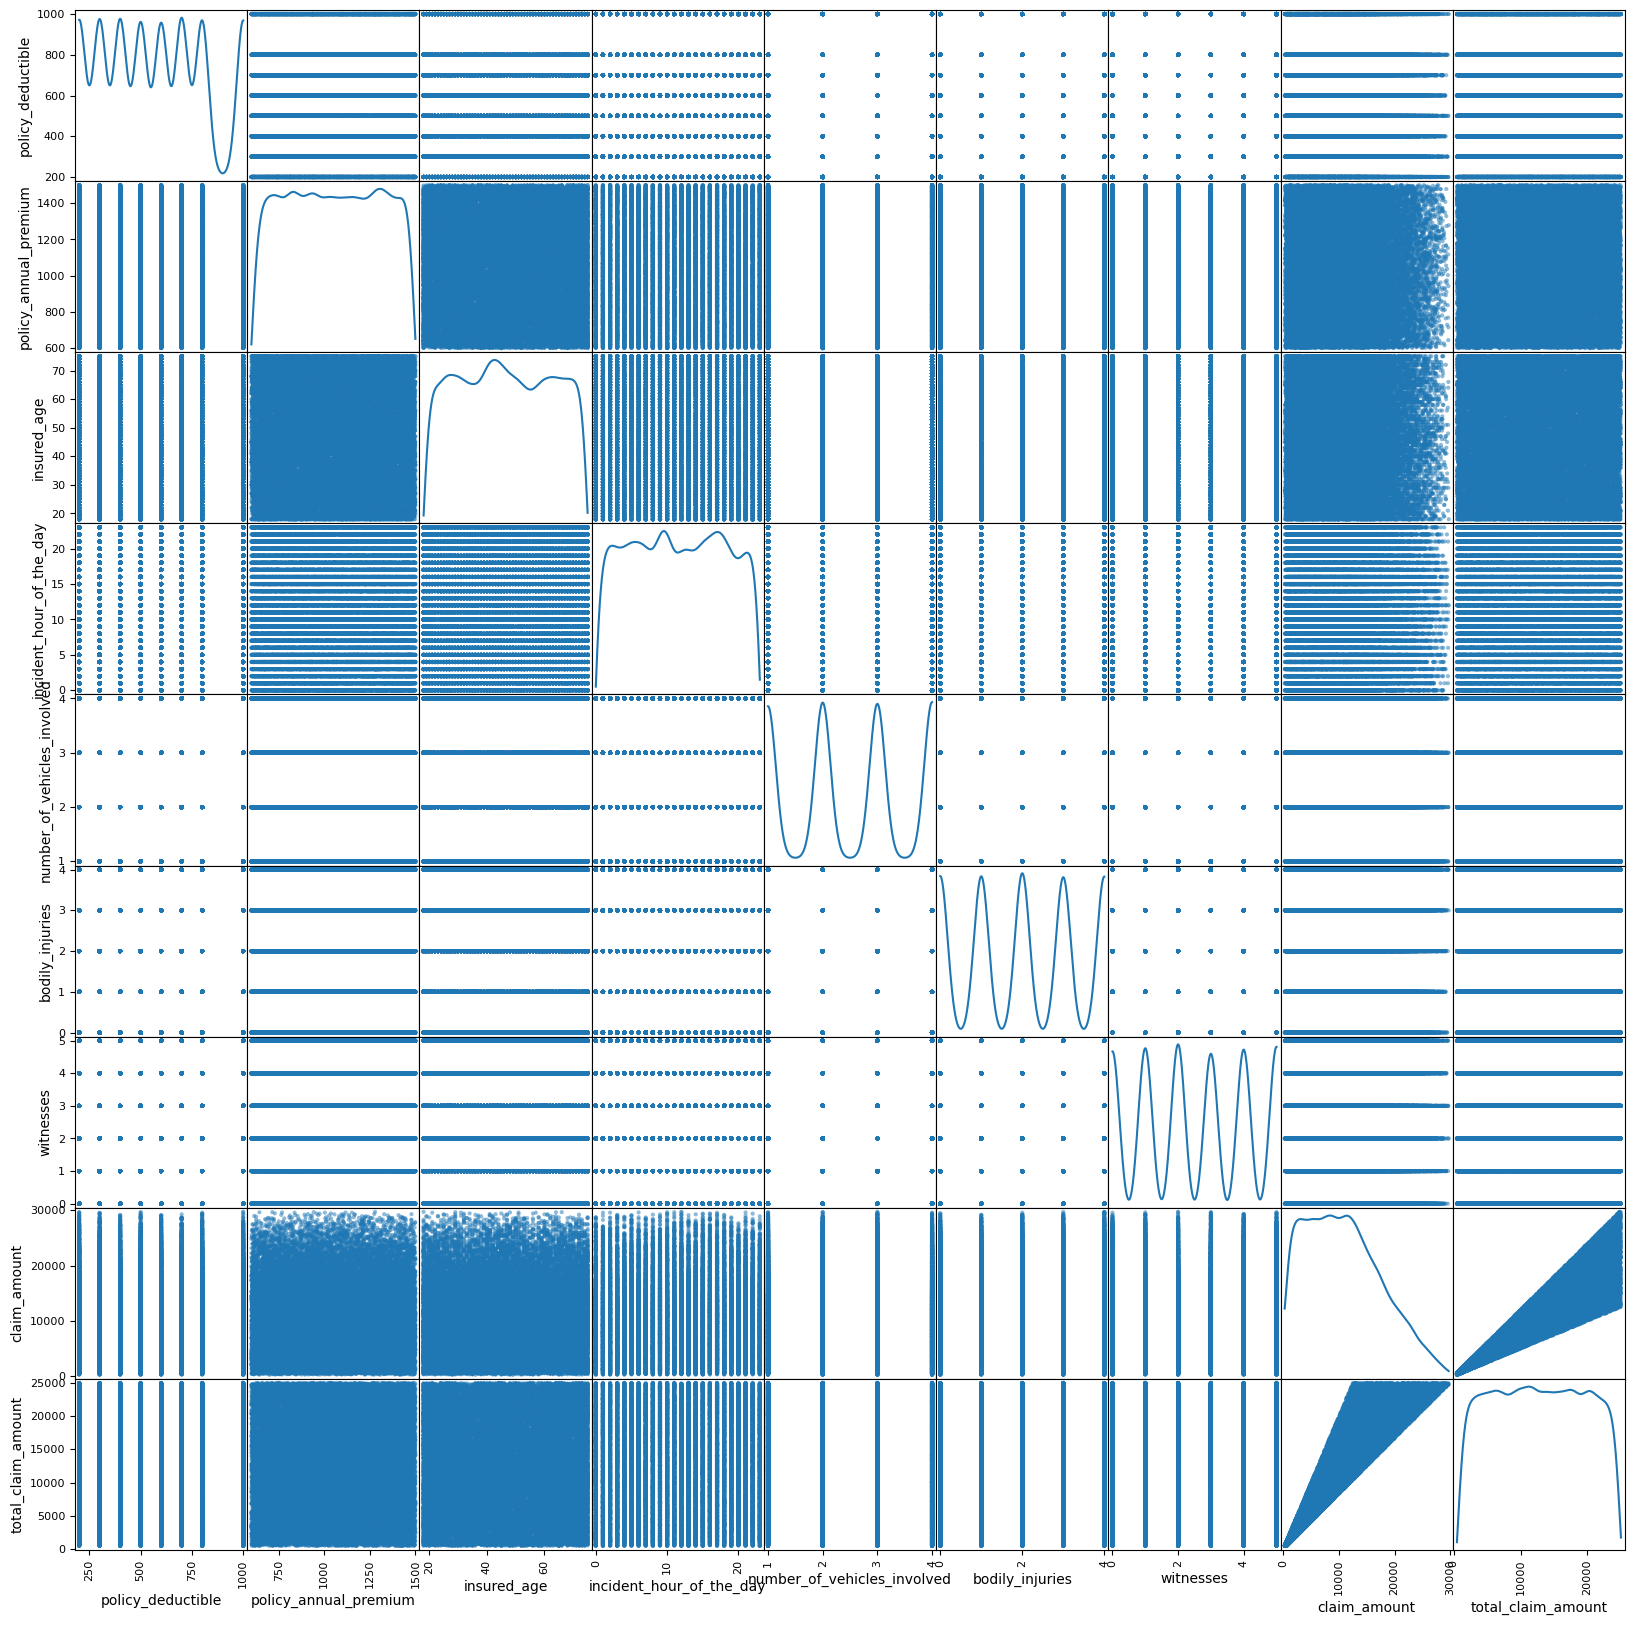

In [7]:
from pandas.plotting import scatter_matrix

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig = plt.figure(1, figsize=(20, 20))
fig.clf()
ax = fig.gca()
scatter_matrix(df[num_cols], alpha=0.5, diagonal='kde', ax=ax)
plt.show()

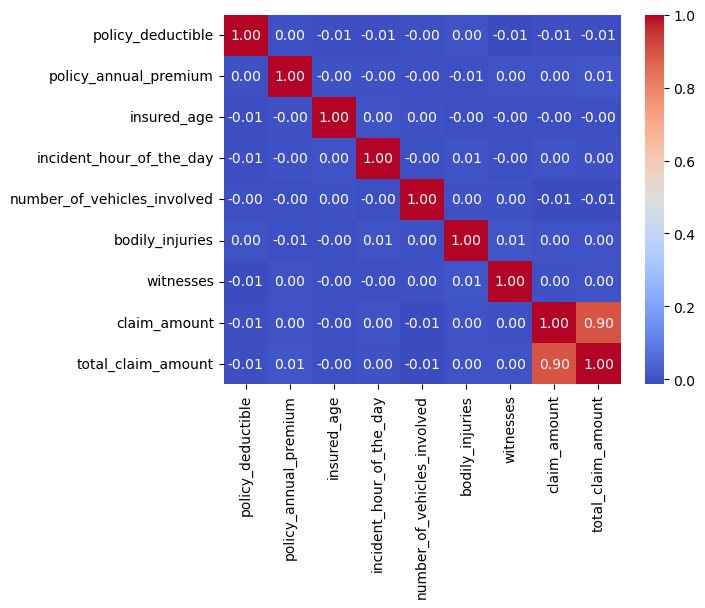

In [8]:
correlation_matrix = df[num_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [9]:
# The column total_claim_amount should be removed because it creates multicollinearity with claim_amount
df = df.drop(columns=['total_claim_amount'])

In [10]:
from scipy.stats import chi2_contingency

target = 'fraud_reported'

cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = [col for col in cat_cols if col != target and df[col].nunique() < 50]

chi2_results = []

for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df[target])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    chi2_results.append({
        'Feature': col,
        'Chi2 Statistics': round(chi2, 2),
        'p-value': round(p, 4),
        'Significant (p < 0.05)': 'Yes' if p < 0.05 else 'No'
    })
    
chi2_df = pd.DataFrame(chi2_results).sort_values(by='p-value')
print(chi2_df)

                    Feature  Chi2 Statistics  p-value Significant (p < 0.05)
3        insured_occupation            69.36   0.0000                    Yes
7         incident_severity           168.30   0.0000                    Yes
8     authorities_contacted           931.77   0.0000                    Yes
10  police_report_available             1.12   0.2908                     No
5             incident_type             2.82   0.4207                     No
1               insured_sex             1.62   0.4442                     No
4           insured_hobbies             4.82   0.5669                     No
2   insured_education_level             1.93   0.5865                     No
9            incident_state             6.81   0.6572                     No
0              policy_state             6.41   0.6979                     No
6            collision_type             0.02   0.9992                     No


The collision_type column is likely to have very similar values across the categories, so it is not as significant.
Although other features are much higher than 0.05, they should still be considered for the modeling step

In [11]:
df = df.drop(columns=['collision_type'])

## Modeling process

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df['fraud_reported'] = df['fraud_reported'].map({'Y': 1, 'N': 0})

X = df.drop(['fraud_reported'], axis=1)
y = df['fraud_reported']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(model, X_train, X_test, y_train, y_test, X_full=None, y_full=None):
    y_pred = model.predict(X_test)
    
    y_pred_train = model.predict(X_train)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    if X_full is not None and y_full is not None:
        print('Model score \t{:2f}'.format(model.score(X_full, y_full)))
    
    print('Score on training data: \t{:2f}'.format(model.score(X_train, y_train)))
    print('Score on test data: \t{:2f}'.format(model.score(X_test, y_test)))
    
    print('Accuracy score: \t{:2f}'.format(accuracy))
    print('Precision score: \t{:2f}'.format(precision))
    print('Recall score: \t{:2f}'.format(recall))
    print('F1 score: \t{:2f}'.format(f1))
    print('\nConfusion matrix: \n', conf_matrix)

### Random Forest model

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('prep', preprocessor),
    ('rf_clf', RandomForestClassifier(
        n_estimators=300, 
        max_depth=6,
        class_weight='balanced',
        min_samples_leaf=5,
        random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['policy_deductible',
                                                   'policy_annual_premium',
                                                   'insured_age',
                                                   'incident_hour_of_the_day',
                                                   'number_of_vehicles_involved',
                                                   'bodily_injuries',
                                                   'witnesses',
                                                   'claim_amount']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['policy_state',
                                                   'insured_sex',
                                                   'insured_education_level',
                                                   'insured_occupation',
                                                   'insured_hobbies',
                                                   'incident_type',
                                                   'incident_severity',
                                                   'authorities_contacted',
                                                   'incident_state',
                                                   'incident_city',
                                                   'police_report_available'])])),
                ('rf_clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])

In [15]:
evaluate_model(rf_model, X_train, X_test, y_train, y_test, X, y)

Model score 	0.671200
Score on training data: 	0.670583
Score on test data: 	0.673667
Accuracy score: 	0.673667
Precision score: 	0.203271
Recall score: 	0.632267
F1 score: 	0.307638

Confusion matrix: 
 [[3607 1705]
 [ 253  435]]


The top left result in the confusion matrix (currently at 3,607) mean that these are legitimate claims that were correctly identified.
The bottom left (at 253) cases are fraud cases missed.
The bottom right (at 435) are fraudulent cases that were successfully caught by the model.
The recall score, which is the main metric for this type of project, is at 63.2%, which means the model is flagging 2 out of every 3 fraud cases that come through the pipeline.
The precision score, however, is at 20.3% (which is a result obtained from 435 / 1,703 + 435), which entails that only 20% of the cases are actually fraudulent, and the rest 80% are false alarms

### XGBoost model

In [16]:
from xgboost import XGBClassifier

# This ratio value was obtained from a previous model run where recall score
# was very low, but precision was better than the tree model.
# This value calculates total negative claims (not fraud) divided by 
# total positive claims (fraud), which gives a ratio of approx 7.7
ratio = 5312 / 688

xgb_model = Pipeline([
    ('prep', preprocessor),
    ('xgb_clf', XGBClassifier(
        scale_pos_weight=ratio,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        random_state=42,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        n_jobs=-1
    ))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['policy_deductible',
                                                   'policy_annual_premium',
                                                   'insured_age',
                                                   'incident_hour_of_the_day',
                                                   'number_of_vehicles_involved',
                                                   'bodily_injuries',
                                                   'witnesses',
                                                   'claim_amount']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['policy_state',
                                                   'insured_sex',
                                                   'insured_education...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.03,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [17]:
evaluate_model(xgb_model, X_train, X_test, y_train, y_test, X, y)

Model score 	0.767467
Score on training data: 	0.771292
Score on test data: 	0.752167
Accuracy score: 	0.752167
Precision score: 	0.259482
Recall score: 	0.626453
F1 score: 	0.366965

Confusion matrix: 
 [[4082 1230]
 [ 257  431]]


These new results are more promising because false alarms have dropped from 1,705 to 1,230, which means this model saved the fraud investigation team from having to examine 475 potentially innocent claims.
The recall score is tied with the random forest model.
XGBoost achieved 5% more in precision.
Overall, XGBoost model should be used for fraud detection.

## Stratified K-Fold Cross-Validation

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(xgb_model, X, y, cv=skf, scoring='f1')

print('For XGBoost model')
print('F1-Scores for each fold: ', f1_scores)
print(f'Mean Cross-Validated F1-Score: {f1_scores.mean():.4f}')

For XGBoost model
F1-Scores for each fold:  [0.36213311 0.35576114 0.36447039 0.3626511  0.35555556]
Mean Cross-Validated F1-Score: 0.3601


In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = cross_val_score(rf_model, X, y, cv=skf, scoring='f1')

print('For Random Forest model')
print('F1-Scores for each fold: ', f1_scores)
print(f'Mean Cross-Validated F1-Score: {f1_scores.mean():.4f}')

For Random Forest model
F1-Scores for each fold:  [0.32680723 0.30845017 0.31493277 0.31372549 0.32327747]
Mean Cross-Validated F1-Score: 0.3174


## Mock test

In [20]:
def test_single_claim(model, clean_feature_columns, raw_claim_dict):
    new_claim_df = pd.DataFrame([raw_claim_dict])
    
    new_claim_df = new_claim_df[clean_feature_columns]
    
    prob = model.predict_proba(new_claim_df)[0][1]
    prediction = model.predict(new_claim_df)[0]
    
    print('Results:')
    print(f'Fraud probability: {prob * 100:.2f}%')
    
    if prediction == 1:
        print('High risk: Manual investigation should take place')
    else:
        print('Low risk: Likely standard claim')
        
model_features = X.columns.tolist()

mock_claim = {
    'policy_id': 'Random Id',
    'policy_state': 'NY',
    'policy_deductible': '600',
    'policy_annual_premium': '1430',
    'insured_age': '70',
    'insured_sex': 'MALE',
    'insured_education_level': 'High School',
    'insured_occupation': 'Teacher',
    'insured_hobbies': 'reading',
    'incident_date': '2024-06-13',
    'incident_type': 'Parked Car',
    'collision_type': 'Front',
    'incident_severity': 'Minor Damage',
    'authorities_contacted': 'None',
    'incident_state': 'MI',
    'incident_city': 'Charlesville',
    'incident_hour_of_the_day': 12,
    'number_of_vehicles_involved': 1,
    'bodily_injuries': 0,
    'witnesses': 0,
    'police_report_available': 'Yes',
    'claim_amount': 8000,
    'total_claim_amount': 12000 
}

test_single_claim(xgb_model, model_features, mock_claim)

Results:
Fraud probability: 19.84%
Low risk: Likely standard claim
